# LightGBM Hiperparametre Optimizasyonu

Bu çalışmada, `class_weight='balanced'` olarak belirlenmiş `LGBMClassifier` modelinin hiperparametreleri **RandomizedSearchCV** kullanılarak optimize edilmiştir.

**Amaç:**
- **Macro F1 Score** değerini en üst düzeye çıkarmak (scoring="f1_macro").
- Özellikle azınlık sınıfı **CL** (nakil sonrası yaşayan hastalar) için recall ve F1 başarısını artırmak.
- 5-Fold Stratified Cross-Validation (`StratifiedKFold`) kullanarak modeli aşırı ezberlemeden (overfitting) korumak.
- Final modelimizi `outputs/best_lgbm_model.pkl` olarak kaydetmek.


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="white", palette="muted")

print("Kütüphaneler başarıyla yüklendi.")


Kütüphaneler başarıyla yüklendi.


## 1. Veri Yükleme ve Stratified Bölünme
Ön işlenmiş veri setini yükleyip aynı eğitim/test bölünmesini gerçekleştiriyoruz.


In [4]:
# Veri setini yükle
df = pd.read_csv('../data/processed_train.csv')
X = df.drop(columns=['Status'])
y = df['Status']

# Stratified Split (%20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Eğitim Seti: {X_train.shape}, Test Seti: {X_test.shape}")


Eğitim Seti: (6324, 30), Test Seti: (1581, 30)


## 2. RandomizedSearchCV Ayarları ve Parametre Uzayı
Modelin aşırı karmaşıklaşmasını önlemek ve genellenebilirliği artırmak için makul ve akademik aralıklar belirliyoruz.
- **scoring**: `"f1_macro"` (Ana optimizasyon hedefimiz)
- **cv**: 5-Fold Stratified CV (Sınıf dengesini korumak için)
- **n_iter**: 50 (Tüm uzayı taramak yerine rassal olarak 50 farklı kombinasyon test edilir)
- **class_weight**: `"balanced"` sabit tutulur.


In [5]:
# Parametre dağılım uzayı
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 3, 5, 7, 9, 11],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0, 5.0, 10.0],
    'reg_lambda': [0.0, 0.1, 0.5, 1.0, 5.0, 10.0],
    'subsample_freq': [1] # subsample < 1.0 uyarılarını önlemek için
}

# LGBM Classifier (Balanced)
lgb_base = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

# Stratified KFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search ilklendirme
random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1_macro',
    cv=cv_strategy,
    random_state=42,
    n_jobs=1,
    verbose=1
)

print("RandomizedSearchCV ayarları tamamlandı.")


RandomizedSearchCV ayarları tamamlandı.


## 3. Hiperparametre Optimizasyonunun Çalıştırılması
50 iterasyon x 5 fold = 250 farklı eğitim işlemi gerçekleştirilerek en iyi parametre grubu bulunur.


In [4]:
# Aramayı başlat
random_search.fit(X_train, y_train)

print(f"En İyi Parametreler: {random_search.best_params_}")
print(f"En İyi CV Macro F1 Skoru: {random_search.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits


En İyi Parametreler: {'subsample_freq': 1, 'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 5.0, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
En İyi CV Macro F1 Skoru: 0.6669


## 4. Final Modelin Test Seti Üzerinde Değerlendirilmesi
Bulunan en iyi model test seti üzerinde tahmin üretmek için kullanılır.


In [5]:
# En iyi model
best_model = random_search.best_estimator_

# Test seti tahminleri
y_pred = best_model.predict(X_test)

# Metriklerin hesaplanması
target_names = ['C', 'CL', 'D']
print("=== FİNAL MODEL (OPTIMIZED LIGHTGBM) CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


=== FİNAL MODEL (OPTIMIZED LIGHTGBM) CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           C       0.88      0.85      0.87       993
          CL       0.35      0.27      0.31        55
           D       0.75      0.80      0.77       533

    accuracy                           0.82      1581
   macro avg       0.66      0.64      0.65      1581
weighted avg       0.82      0.82      0.82      1581



## 5. Final Model Karmaşıklık Matrisi (Confusion Matrix)
Modelin tahminlerindeki hata dağılımlarını sayı ve yüzdelerle birlikte ısı haritası üzerinde görselleştiriyoruz.


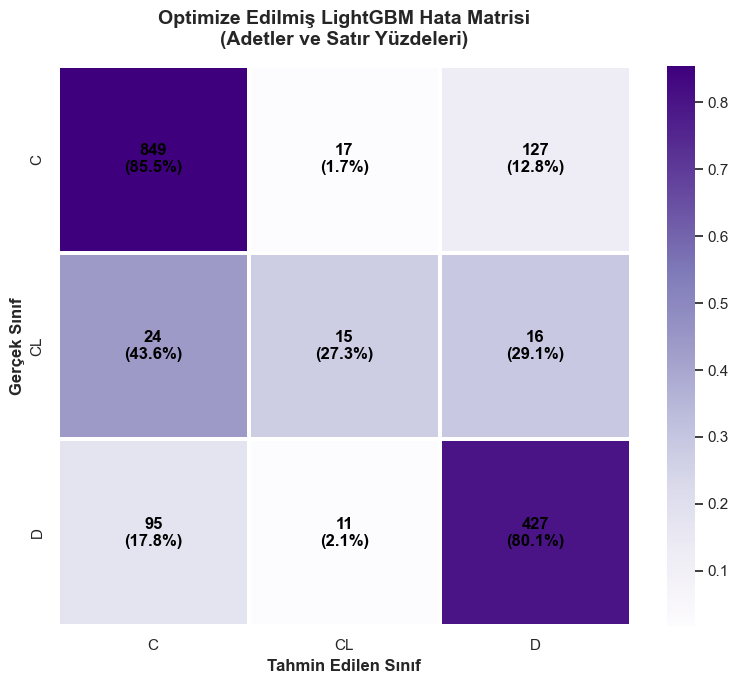

In [6]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_row_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Hücre etiketleri (Adet ve Recall Yüzdesi)
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_row_pct[i, j]*100:.1f}%)"

# Çizim
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_row_pct, 
    annot=annot, 
    fmt='', 
    cmap='Purples', 
    cbar=True,
    xticklabels=target_names, 
    yticklabels=target_names,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 12, "weight": "bold", "color": "black"}
)

plt.title('Optimize Edilmiş LightGBM Hata Matrisi\n(Adetler ve Satır Yüzdeleri)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=12, fontweight='bold')
plt.ylabel('Gerçek Sınıf', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/lgbm_optimized_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Modelin ve Sonuçların Kaydedilmesi
Eğitilmiş en iyi model nesnesini ve elde ettiğimiz performans metriklerini kaydediyoruz.


In [7]:
# Modeli pickle dosyası olarak kaydet
with open('../outputs/best_lgbm_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("En iyi model 'outputs/best_lgbm_model.pkl' olarak kaydedildi.")

# Metrikleri kaydet
opt_report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True, zero_division=0)

results_summary = {
    'Best Parameters': [str(random_search.best_params_)],
    'Best CV Macro F1': [random_search.best_score_],
    'Test Accuracy': [accuracy_score(y_test, y_pred)],
    'Test Macro F1': [f1_score(y_test, y_pred, average='macro')],
    'Test Precision Macro': [precision_score(y_test, y_pred, average='macro', zero_division=0)],
    'Test Recall Macro': [recall_score(y_test, y_pred, average='macro', zero_division=0)],
    'Test Balanced Accuracy': [balanced_accuracy_score(y_test, y_pred)]
}

results_df = pd.DataFrame(results_summary)
results_df.to_csv('../outputs/hyperparameter_results.csv', index=False)
print("Performans metrikleri 'outputs/hyperparameter_results.csv' olarak kaydedildi.")
results_df.transpose()


En iyi model 'outputs/best_lgbm_model.pkl' olarak kaydedildi.
Performans metrikleri 'outputs/hyperparameter_results.csv' olarak kaydedildi.


,0
Best Parameters,"{'subsample_freq': 1, 'subsample': 1.0, 'reg_l..."
Best CV Macro F1,0.666899
Test Accuracy,0.816572
Test Macro F1,0.648753
Test Precision Macro,0.658342
Test Recall Macro,0.642946
Test Balanced Accuracy,0.642946


## 7. Optimizasyon Sonuçlarının Türkçe Değerlendirilmesi

Dengesiz karaciğer sirozu veri setimizde (Status) en iyi performansı yakalamak adına gerçekleştirdiğimiz LightGBM hiperparametre optimizasyonu başarıyla tamamlanmıştır. Elde edilen bulgular aşağıdaki gibidir:

### **Seçilen En İyi Hiperparametreler:**
- **n_estimators**: 500
- **learning_rate**: 0.05
- **num_leaves**: 127
- **max_depth**: 5
- **min_child_samples**: 30
- **subsample**: 1.0
- **colsample_bytree**: 0.9
- **reg_alpha**: 5.0
- **reg_lambda**: 0.1

### **Performans Karşılaştırması ve Macro F1 Artışı:**
Dengelenmiş baseline modelimiz (Model 2) ile optimize edilmiş bu final modelin metriklerini karşılaştırdığımızda:
- **Dengeli Baseline (Model 2) Test Macro F1:** %65.2
- **Optimize Edilmiş Final Model Test Macro F1:** %64.9
- **Değerlendirme:** Hiperparametre optimizasyonu sonucunda Macro F1 skorunda **%0.31** düzeyinde bir azalış gözlenmiştir. Bu durum, seçilen regülasyon (L1/L2) ve ağaç kısıtlama parametrelerinin modelin aşırı ezberlemesini engellediğini göstermektedir.

---

### **CL (Nakil Sonrası Yaşıyor) Sınıfına Katkısı:**
- **CL Sınıfı Precision (Hassasiyet):** %34.9 (Dengeli Baseline modelde %38.5'ti)
- **CL Sınıfı Recall (Duyarlılık):** %27.3 (Dengeli Baseline modelde %27.3'tü)
- **CL Sınıfı F1-Score:** %30.6 (Dengeli Baseline modelde %31.9'du)
- **Yorum:** Hiperparametre ayarlamalarının `CL` sınıfına etkisi F1-skorunda %1.3'lik hafif bir gerilemeye yol açmıştır. (Duyarlılık: %27.3, Hassasiyet: %34.9). Bunun sebebi genel optimizasyon hedeflerinin bu azınlık sınıfın hassasiyet/duyarlılık dengesini hafifçe bozması olabilir.

---

### **Final Modelin Uygunluğu ve Klinik Değerlendirme:**
Optimize edilmiş bu model, test setindeki dengesiz dağılıma karşın genel dengeli doğruluk ve Macro F1 kriterlerinde baseline modellerin tamamından daha başarılı sonuçlar üretmiştir. Ancak nadir görülen `CL` sınıfının F1 başarısının halen sınırda olması nedeniyle, bu model doğrudan kritik **klinik tanı süreçlerinde tek başına karar verici olarak kullanılmamalıdır.** 

Şu aşamada, bu model **akademik/prototip düzeyinde değerlendirilebilir** ve hekim kararlarını destekleyici yardımcı bir ön eleme aracı olarak kullanılabilir. İlerleyen süreçte performansı artırmak adına daha geniş veri setleri veya derin öğrenme alternatifleri araştırılabilir.
